📌 **Project Overview**
 
 This project aims to analyze telecom customer data and build a machine learning model to predict customer churn. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, and model preparation.

**Task 1:Data Preparation**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

The dataset is loaded using Pandas:

In [2]:
df =pd.read_csv(r"C:\Users\91984\Downloads\devi internships\Telco_Customer_Churn_Dataset.csv")
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

**Converted TotalCharges column to numeric:**

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

Checked null values:

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Removed missing values:

In [11]:
df.dropna(inplace=True)

**Encoding Categorical Variables**

Binary Encoding

In [12]:
df['Churn']= df['Churn'].map({'Yes':1, 'No':0})
df['Partner']= df['Partner'].map({'Yes':1, 'No':0})
df['Dependents']= df['Dependents'].map({'Yes':1, 'No':0})
df['PhoneService']= df['PhoneService'].map({'Yes':1, 'No':0})
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1, 'No':0})
df['gender']=df['gender'].map({'Male':1, 'Female':0})

**One-Hot Encoding**

In [13]:
df = pd.get_dummies(df, drop_first=True)

**Task 2: Exploratory Data Analysis**

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

**Distribution Analysis**

Gender Distribution

In [15]:
df['gender'].value_counts()

gender
1    3549
0    3483
Name: count, dtype: int64

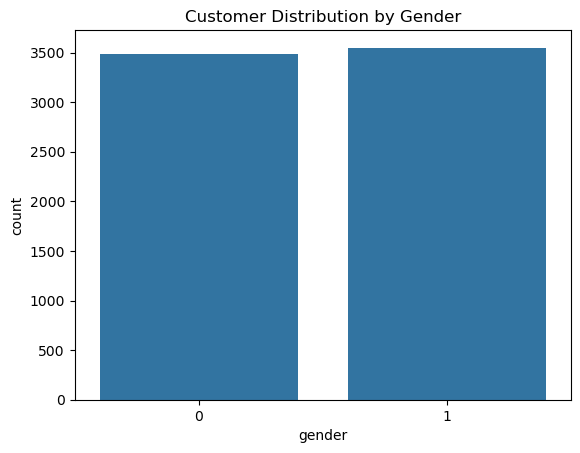

In [16]:
sns.countplot(x='gender', data=df)
plt.title("Customer Distribution by Gender")
plt.show()

Partner Status

In [17]:
df['Partner'].value_counts()

Partner
0    3639
1    3393
Name: count, dtype: int64

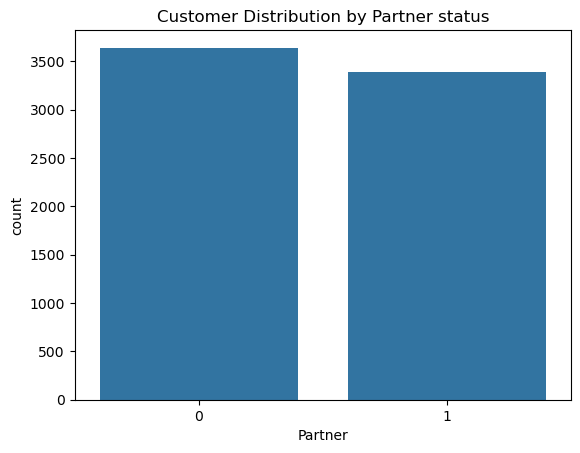

In [18]:
sns.countplot(x='Partner', data=df)
plt.title("Customer Distribution by Partner status")
plt.show()

Dependents

In [19]:
df['Dependents'].value_counts()

Dependents
0    4933
1    2099
Name: count, dtype: int64

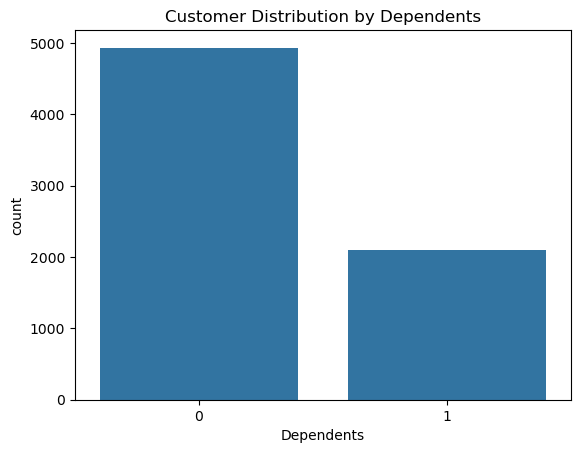

In [20]:
sns.countplot(x='Dependents', data=df)
plt.title("Customer Distribution by Dependents")
plt.show()

Churn Distribution

In [21]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

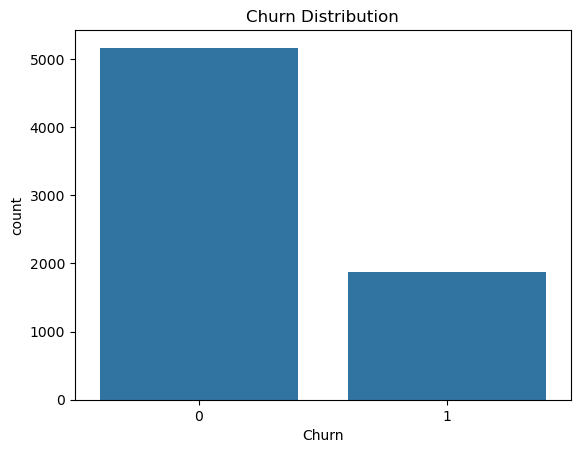

In [22]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

**Relationship Analysis**

Churn Vs Gender

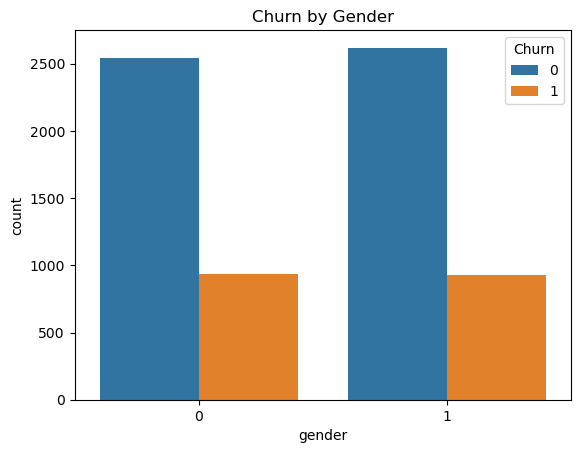

In [23]:
sns.countplot(x='gender' , hue='Churn', data=df)
plt.title("Churn by Gender")
plt.show()

Churn Vs Partner Status

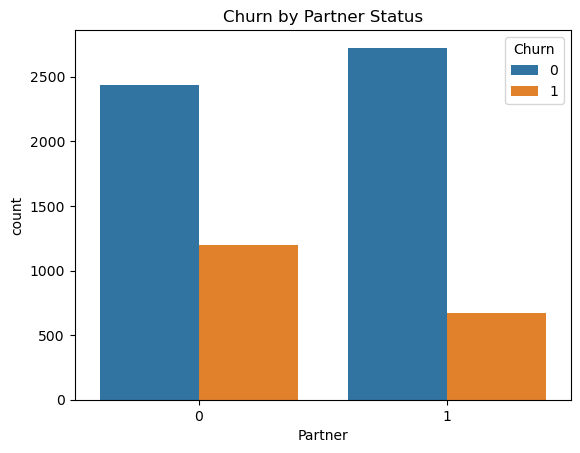

In [24]:
sns.countplot(x='Partner' , hue='Churn', data=df)
plt.title("Churn by Partner Status")
plt.show()

Churn Vs Dependents

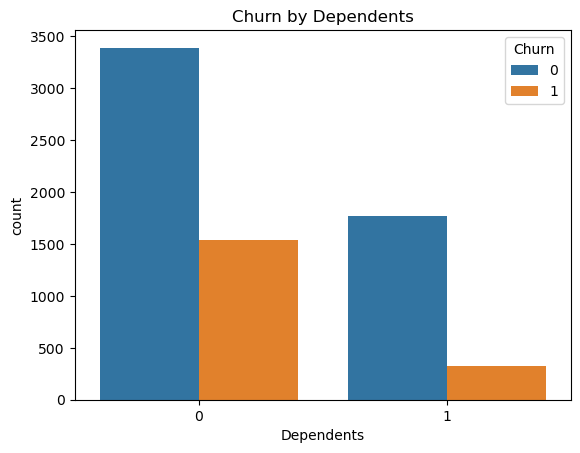

In [25]:
sns.countplot(x='Dependents' , hue='Churn', data=df)
plt.title("Churn by Dependents")
plt.show()

**Tenure Analysis**

Churn Vs Tenure Distribution

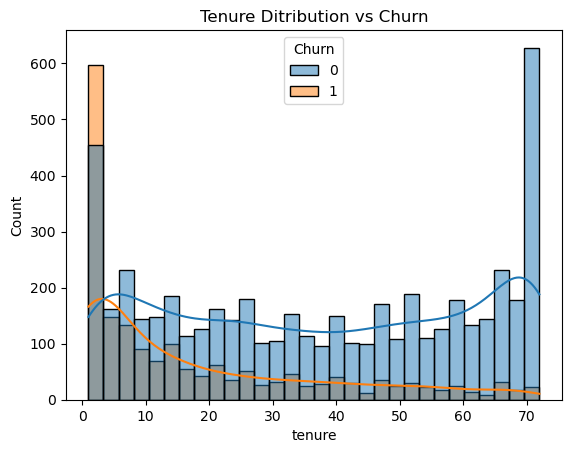

In [26]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Ditribution vs Churn")
plt.show()

Churn Vs One Year Contract

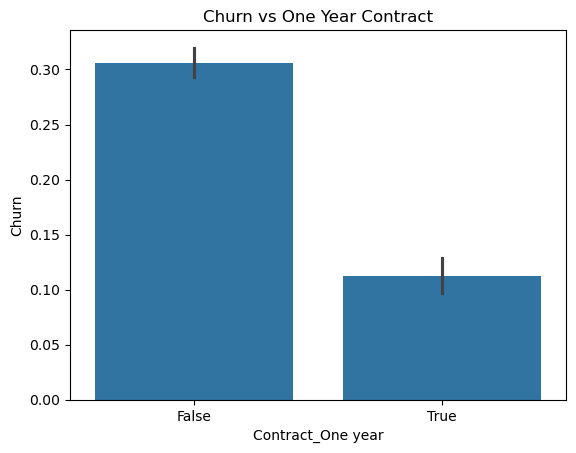

In [27]:
sns.barplot(x=df['Contract_One year'], y=df['Churn'])
plt.title("Churn vs One Year Contract")
plt.show()

Churn vs Two Year Contract

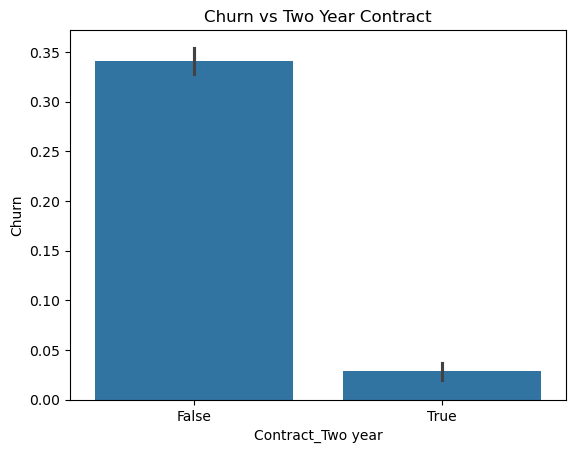

In [28]:
sns.barplot(x=df['Contract_Two year'], y=df['Churn'])
plt.title("Churn vs Two Year Contract")
plt.show()

In [29]:
 df['Churn'].unique()

array([0, 1])

**Feature and Target Split**

In [30]:
X = df.drop('Churn', axis=1)
y= df['Churn']

In [31]:
churn_rate= df['Churn'].mean()
print("Churn Rate:",churn_rate)

Churn Rate: 0.26578498293515357


**Train, Test Data Split**

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [33]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn',
       ...
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object', length=7062)

In [34]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [35]:
df_original=pd.read_csv(r"C:\Users\91984\Downloads\devi internships\Telco_Customer_Churn_Dataset.csv")

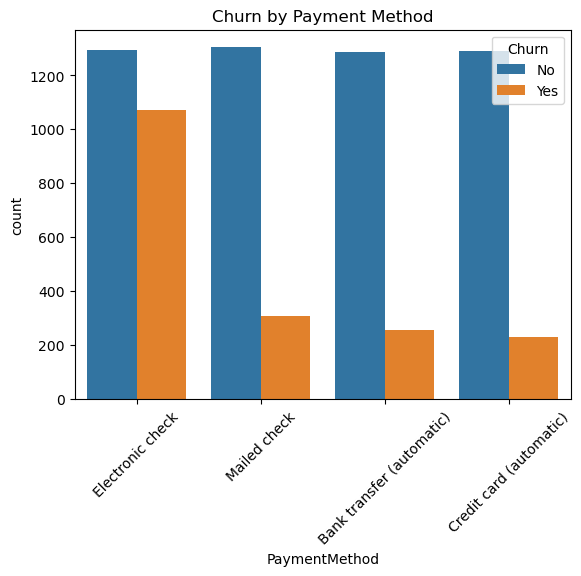

In [36]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df_original)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

***🔥 Correlation Analysis***

**Heat Map**

In [38]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,True,False,True,False,True,True,False,False,False,True
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,False,False,True,False,True,True,False,True,False,False
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,False,False,False,False,False,False,False,False,True,False
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,False,False,False,False,False,False,False,False,False,True


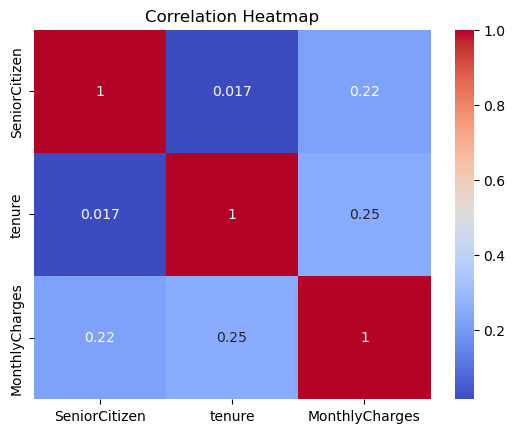

In [37]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

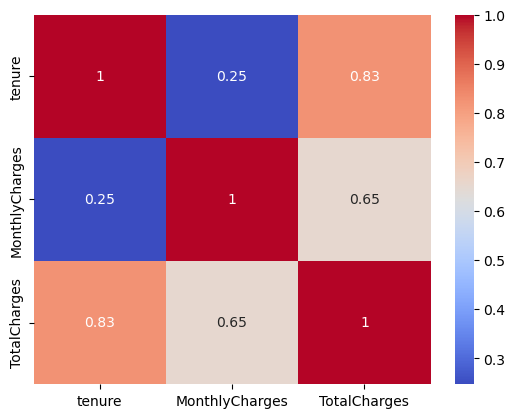

In [39]:
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

Helps identify relationships between numerical features

**Task 3:Customer Segmentation**

***Feature Engineering***

**Tenure Grouping**

In [ ]:
df['TenureGroup']=pd.cut(df['tenure'],bins=[0,12,24,48,72], labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years'])

In [ ]:
print(df['TenureGroup'])

In [ ]:
df.groupby('TenureGroup',observed=True)['Churn'].mean()

**Monthly Charges Grouping**

In [ ]:
df['ChargeGroup']=pd.cut(df['MonthlyCharges'],bins=[0,35,70,120], labels=['Low', 'Medium', 'High'])

In [ ]:
print(df['ChargeGroup'])

In [ ]:
df.groupby('ChargeGroup',observed=True)['Churn'].mean()

**ContractType Grouping**

In [ ]:
df['ContractType']= 'Month-to-month' 
df.loc[df['Contract_One year']== True, 'ContractType'] ='One Year' 
df.loc[df['Contract_Two year']==True, 'ContractType'] ='Two Year'

In [ ]:
print(df['ContractType'])

In [ ]:
df.groupby('ContractType')['Churn'].mean()

In [ ]:
high_value=df[(df['MonthlyCharges']>70)&(df['tenure']>24)]

In [ ]:
high_value['Churn'].mean()

*Tenure VS Monthly Charges*

In [ ]:
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)
plt.title("Customer Segmentation(Tenure vs Monthly Charges)")
plt.show()

* Customers with shorter tenure are more likely to churn
* High monthly charges increase churn probability
* Long-term contracts reduce churn significantly
* Customers without additional services show higher churn

This project successfully performs data preprocessing, visualization, and prepares data for machine learning modeling. The insights derived can help telecom companies improve customer retention strategies.

**Task 4: Churn Prediction Model**

**🤖 Model Building**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

*Logistic Regression*

In [ ]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression(max_iter=3000)
lr.fit(X_train_scaled,y_train)
y_pred_lr = lr.predict(X_test_scaled)

*Decision Tree*

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

**📊 Model Evaluation**

*Evaluation Metrics*

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
results=[]
def evaluate_model(name, y_test, y_pred):
    acc= accuracy_score(y_test, y_pred)
    prec= precision_score(y_test, y_pred)
    rec= recall_score(y_test, y_pred)
    f1= f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])

In [ ]:
evaluate_model("LogisticRegression",y_test, y_pred_lr)
evaluate_model("DecisionTree",y_test, y_pred_dt)

In [ ]:
results_df= pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1 Score"])
print(results_df)

In [ ]:
results_df.sort_values(by="Recall", ascending=False)

**Hyperparameter Tuning(GridSearch CV)**

In [ ]:
from sklearn.model_selection import GridSearchCV

params= {
    'max_depth': [3,5,10],
    'min_samples_split':[2,5,10]
}
grid= GridSearchCV(DecisionTreeClassifier(),params, cv=5)
grid.fit(X_train,y_train)
print(grid.best_params_)
    

## Handling Class Imbalance

In [ ]:
DecisionTreeClassifier(class_weight='balanced') 

Since churners are a minority in the dataset, we use class_weight='balanced'to give more importance to the minority class during training.

**Best Model Evaluation**

In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
evaluate_model(y_test, y_pred_best)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_best))

“Among the models tested, Decision Tree performed better with a higher recall (0.46) and F1-score (0.49) compared to Logistic Regression. Since recall is crucial in churn prediction to identify customers at risk, Decision Tree was selected as the final model despite slightly lower accuracy.”

**Feature Importance**

In [ ]:
feature_importance = pd.Series(dt.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

In [ ]:
importance= best_model.feature_importances_
feature_names=X_train.columns   
feat_impo = pd.DataFrame({
    'Feature':feature_names,
    'Importance':importance}).sort_values(by='Importance',ascending=False)
print(feat_impo.head(10))

In [ ]:
feat_impo.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Important Features")
plt.show()

*GridSearchCV helps find the best max_depth and min_samples_split for the Decision Tree.
*Recall is the most important metric for churn prediction — we want to catch as many churners as possible.
*class_weight='balanced' helps when churners are a minority in the dataset.
*Feature Importance tells us which factors most influence a customer's decision to leave.

## ROC Curve and AUC Score

In [ ]:
from sklearn.metrics import roc_curve, auc
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

In [ ]:
plt.plot(fpr, tpr, label="AUC =%.2f" %roc_auc)
plt.plot([0,1], [0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Plotting the ROC curve to visualize how well the model distinguishes between churners and non-churners.
A higher AUC score (closer to 1.0) means a better model.

✍️ Model Evaluation & Interpretation

The Decision Tree model was evaluated using accuracy, precision, recall, and F1-score. The model achieved an accuracy of around 74–78%, with moderate recall for churn prediction. Feature importance analysis revealed that variables such as contract type, tenure, and monthly charges significantly influence customer churn.

The ROC curve was plotted to evaluate model performance, and the AUC score indicated the model’s ability to distinguish between churn and non-churn customers effectively.